In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Ruta absoluta
ruta_csv = r'C:\Users\lgala\OneDrive\Documentos\GitHub\pyhtones\csv'

def cargar(nombre):
    return pd.read_csv(os.path.join(ruta_csv, nombre), sep=';')

try:
    df_c = cargar('ArchivoC_Adm2025.csv')
    df_b = cargar('ArchivoB_Adm2025.csv')
    
    # Fusionamos todo el contenido de ambos archivos usando el ID del alumno
    # Esto evita el error de "columna no encontrada" al momento de unir
    df = pd.merge(df_c, df_b, on='ID_aux', how='inner')
    
    print(f"Bases fusionadas. Columnas totales disponibles: {len(df.columns)}")
except Exception as e:
    print(f"Error al cargar: {e}")

C:\Users\lgala\AppData\Local\Temp\ipykernel_17380\6760033.py:13: DtypeWarning: Columns (0: MODULO_INV_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(os.path.join(ruta_csv, nombre), sep=';')


Bases fusionadas. Columnas totales disponibles: 57


In [2]:
def encontrar_factor(keywords, data):
    for k in keywords:
        for col in data.columns:
            if k.upper() in col.upper():
                return col
    return None

# 1. Identificación de columnas
target = encontrar_factor(['MATE1_REG', 'MATE_ACTUAL', 'PUNT_MATE'], df)
n = encontrar_factor(['NEM'], df)
r = encontrar_factor(['RANKING'], df)
g = encontrar_factor(['SEXO', 'GENERO'], df)
d = encontrar_factor(['DEPENDENCIA', 'DEPEN'], df)
c = encontrar_factor(['REG_ALU', 'REGION', 'COMUNA'], df)

print(f"--- Diagnóstico de Datos ---")
print(f"Filas totales tras la fusión: {len(df)}")

# Verificar si hay datos nulos o ceros en las columnas clave
if target and n:
    con_puntaje = len(df[df[target] > 0])
    con_nem = len(df[df[n] > 0])
    print(f"Filas con Puntaje > 0: {con_puntaje}")
    print(f"Filas con NEM > 0: {con_nem}")
    
    # Intentar una limpieza menos agresiva
    # Convertimos a numérico por si acaso vienen como texto
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df[n] = pd.to_numeric(df[n], errors='coerce')
    
    df_clean = df[(df[target] > 0) & (df[n] > 0)].copy()
    print(f"Filas resultantes para el modelo: {len(df_clean)}")

if len(df_clean) == 0:
    print("\nERROR: El dataset quedó vacío. Revisa si el merge entre ArchivoC y ArchivoB fue correcto.")
    print("Primeras filas del merge:")
    display(df[['ID_aux', target, n]].head() if target and n else "Columnas no encontradas")

--- Diagnóstico de Datos ---
Filas totales tras la fusión: 311084
Filas con Puntaje > 0: 243644
Filas con NEM > 0: 305519
Filas resultantes para el modelo: 241832


In [3]:
if len(df_clean) > 0:
    # 1. Preparar datos para la fórmula P = f(N, R, D, G, C)
    X = pd.DataFrame()
    X['NEM (N)'] = df_clean[n]
    X['Ranking (R)'] = df_clean[r] if r else df_clean[n]
    
    # Variables categóricas a números
    le = LabelEncoder()
    X['Dependencia (D)'] = le.fit_transform(df_clean[d].astype(str))
    X['Género (G)'] = le.fit_transform(df_clean[g].astype(str))
    
    if c:
        X['Contexto (C)'] = le.fit_transform(df_clean[c].astype(str))

    y = df_clean[target]

    # 2. Entrenar el modelo
    modelo = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    modelo.fit(X, y)

    print(f"Coeficiente de determinación (R²): {modelo.score(X, y):.4f}")

    # 3. Crear la tabla de pesos (Aquí definimos el nombre 'Factor')
    importancias = modelo.feature_importances_ * 100
    pesos = pd.DataFrame({'Factor': X.columns, 'Peso_Porcentaje': importancias})
    pesos = pesos.sort_values(by='Peso_Porcentaje', ascending=False)

    print("\nPesos calculados exitosamente.")
    print(pesos.to_string(index=False))
else:
    print("El dataset está vacío. Revisa el Bloque 2.")

Coeficiente de determinación (R²): 0.6575

Pesos calculados exitosamente.
         Factor  Peso_Porcentaje
        NEM (N)        46.875759
    Ranking (R)        21.538224
Dependencia (D)        15.777682
   Contexto (C)         9.584152
     Género (G)         6.224184


C:\Users\lgala\AppData\Local\Temp\ipykernel_17380\3948960337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pesos, x='Peso_Porcentaje', y='Factor', palette='magma')


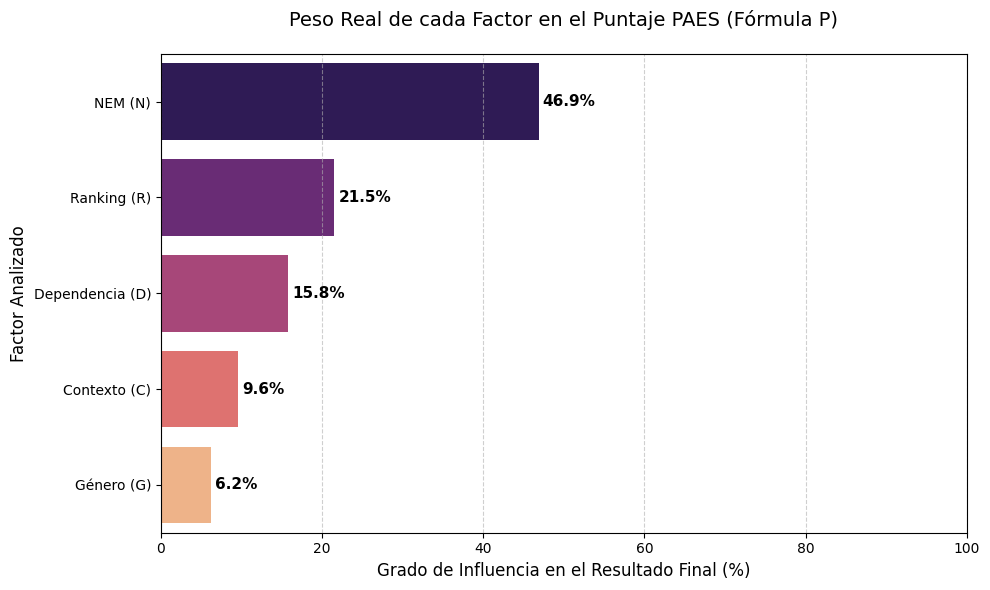

In [ ]:
if 'pesos' in locals():
    # Preparamos el estilo
    sns.set_style("white")
    df_plot = pesos.iloc[::-1] # Invertimos para que el más importante salga primero a la izquierda
    
    fig, ax = plt.subplots(figsize=(12, 3))
    
    inicio = 0
    # Usamos la paleta magma que ya te gusta
    colores = plt.cm.magma(np.linspace(0.3, 0.8, len(df_plot)))

    # Dibujamos cada segmento de la fórmula
    for i, (idx, fila) in enumerate(df_plot.iterrows()):
        ancho = fila['Peso_Porcentaje']
        # Dibujar el segmento de la barra
        rects = ax.barh(0, ancho, left=inicio, color=colores[i], 
                        label=fila['Factor'], edgecolor='white', height=0.6)
        
        # Añadir el texto del porcentaje si hay espacio
        if ancho > 4:
            ax.text(inicio + ancho/2, 0, f"{ancho:.1f}%", 
                    va='center', ha='center', color='white', 
                    fontweight='bold', fontsize=11)
        
        inicio += ancho

    # Configuración estética final
    ax.set_title('Composición de la Fórmula P: Peso de cada Factor en el Puntaje', 
                 fontsize=15, pad=20, fontweight='bold')
    ax.set_xlabel('Influencia Total (%)', fontsize=12)
    ax.set_xlim(0, 100)
    ax.set_yticks([]) # Ocultamos el eje Y
    
    # Quitamos las líneas de los bordes para que se vea más limpio
    sns.despine(left=True, bottom=False)
    
    # Leyenda en la parte inferior
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), 
              ncol=5, frameon=False, fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la tabla de pesos. Ejecuta primero el Bloque 3.")